
# AI5707 – Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

**Objective:** Estimate Gaussian class parameters using Maximum Likelihood Estimation (MLE), classify test samples, visualize decision boundaries, and generate confusion matrices.

This notebook follows the assignment specification: three Gaussian classes, approximately 10,000 samples per class, 80/20 train-test split, spherical/diagonal/full covariance models, common and class-specific covariance experiments, decision-boundary plots, confusion matrices, observations, and a template for the supplied real 2-D dataset.



### Important assumption for Part 1

The assignment refers to “the program from the last assignment” but that program/data is not included in the supplied Assignment 5 PDF. Therefore, this notebook uses a clearly stated synthetic 2-D Gaussian setup:

- Class means: μ₁ = [2, 2], μ₂ = [7, 3], μ₃ = [4, 7]
- 10,000 points per class
- Three covariance structures:
  1. Spherical: σ²I
  2. Diagonal: diag(σ₁², σ₂²)
  3. Full covariance matrix
- Two covariance conditions:
  - Common covariance across classes
  - Different covariance matrices across classes

The MLE formulas are implemented directly rather than using a pre-trained classifier.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

np.random.seed(42)

N_PER_CLASS = 10_000
means = np.array([
    [2.0, 2.0],
    [7.0, 3.0],
    [4.0, 7.0]
])

# Covariance choices used for the experiments
cov_spherical_common = [
    2.0 * np.eye(2),
    2.0 * np.eye(2),
    2.0 * np.eye(2)
]

cov_diagonal_common = [
    np.diag([1.0, 3.0]),
    np.diag([1.0, 3.0]),
    np.diag([1.0, 3.0])
]

cov_full_common = [
    np.array([[2.0, 0.8], [0.8, 1.5]]),
    np.array([[2.0, 0.8], [0.8, 1.5]]),
    np.array([[2.0, 0.8], [0.8, 1.5]])
]

cov_spherical_different = [
    1.0 * np.eye(2),
    2.5 * np.eye(2),
    4.0 * np.eye(2)
]

cov_diagonal_different = [
    np.diag([1.0, 2.0]),
    np.diag([2.0, 4.0]),
    np.diag([4.0, 1.0])
]

cov_full_different = [
    np.array([[1.5, 0.5], [0.5, 1.0]]),
    np.array([[2.5, -0.8], [-0.8, 1.5]]),
    np.array([[1.8, 0.9], [0.9, 3.0]])
]

covariance_sets = {
    "Spherical - common": cov_spherical_common,
    "Diagonal - common": cov_diagonal_common,
    "Full - common": cov_full_common,
    "Spherical - different": cov_spherical_different,
    "Diagonal - different": cov_diagonal_different,
    "Full - different": cov_full_different,
}


## 1. Generate approximately 10,000 samples for each class

In [3]:

def generate_gaussian_data(means, covariances, n_per_class=10_000, seed=42):
    rng = np.random.default_rng(seed)
    X_parts, y_parts = [], []

    for k, (mu, cov) in enumerate(zip(means, covariances)):
        Xk = rng.multivariate_normal(mu, cov, size=n_per_class)
        yk = np.full(n_per_class, k)
        X_parts.append(Xk)
        y_parts.append(yk)

    return np.vstack(X_parts), np.concatenate(y_parts)


X, y = generate_gaussian_data(
    means,
    cov_full_different,
    n_per_class=N_PER_CLASS,
    seed=42
)

print("Total samples:", len(X))
print("Samples per class:", np.bincount(y))


Total samples: 30000
Samples per class: [10000 10000 10000]



## 2. Maximum Likelihood Estimation

For class \(i\), with \(N_i\) training samples \(x_1,\ldots,x_{N_i}\), the Gaussian MLEs are:

\[
\hat{\mu}_i = \frac{1}{N_i}\sum_{n=1}^{N_i}x_n
\]

\[
\hat{\Sigma}_i =
\frac{1}{N_i}\sum_{n=1}^{N_i}
(x_n-\hat{\mu}_i)(x_n-\hat{\mu}_i)^T
\]

Notice the denominator is **\(N_i\)**, not \(N_i-1\), because this is the maximum-likelihood estimate rather than the unbiased sample covariance estimate.

For classification, the Gaussian log-discriminant is:

\[
g_i(x)= -\frac12\log|\Sigma_i|
-\frac12(x-\mu_i)^T\Sigma_i^{-1}(x-\mu_i)
+\log P(\omega_i)
\]

with equal class priors \(P(\omega_i)=1/3\).


In [4]:

def estimate_gaussian_parameters(X_train, y_train, covariance_mode="full"):
    classes = np.unique(y_train)
    mus, covs, priors = {}, {}, {}

    for c in classes:
        Xc = X_train[y_train == c]
        mu = Xc.mean(axis=0)
        centered = Xc - mu
        cov_full = (centered.T @ centered) / len(Xc)

        if covariance_mode == "full":
            cov = cov_full
        elif covariance_mode == "diagonal":
            cov = np.diag(np.diag(cov_full))
        elif covariance_mode == "spherical":
            sigma2 = np.trace(cov_full) / Xc.shape[1]
            cov = sigma2 * np.eye(Xc.shape[1])
        else:
            raise ValueError("covariance_mode must be 'spherical', 'diagonal', or 'full'")

        # Small regularization only for numerical stability.
        cov = cov + 1e-9 * np.eye(cov.shape[0])

        mus[c] = mu
        covs[c] = cov
        priors[c] = len(Xc) / len(X_train)

    return mus, covs, priors


def gaussian_log_discriminants(X, mus, covs, priors):
    classes = sorted(mus.keys())
    scores = np.zeros((len(X), len(classes)))

    for j, c in enumerate(classes):
        mu = mus[c]
        cov = covs[c]
        sign, logdet = np.linalg.slogdet(cov)
        inv_cov = np.linalg.inv(cov)

        d = X - mu
        mahal = np.einsum("ij,jk,ik->i", d, inv_cov, d)

        scores[:, j] = (
            -0.5 * logdet
            -0.5 * mahal
            + np.log(priors[c])
        )

    return scores


def classify_gaussian(X, mus, covs, priors):
    scores = gaussian_log_discriminants(X, mus, covs, priors)
    classes = np.array(sorted(mus.keys()))
    return classes[np.argmax(scores, axis=1)]


## 3. 80% training / 20% testing split

In [5]:

def split_data(X, y, seed=42):
    return train_test_split(
        X, y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )


X_train, X_test, y_train, y_test = split_data(X, y)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Train class counts:", np.bincount(y_train))
print("Test class counts :", np.bincount(y_test))


Training samples: 24000
Testing samples : 6000
Train class counts: [8000 8000 8000]
Test class counts : [2000 2000 2000]


## 4. Visualize generated data

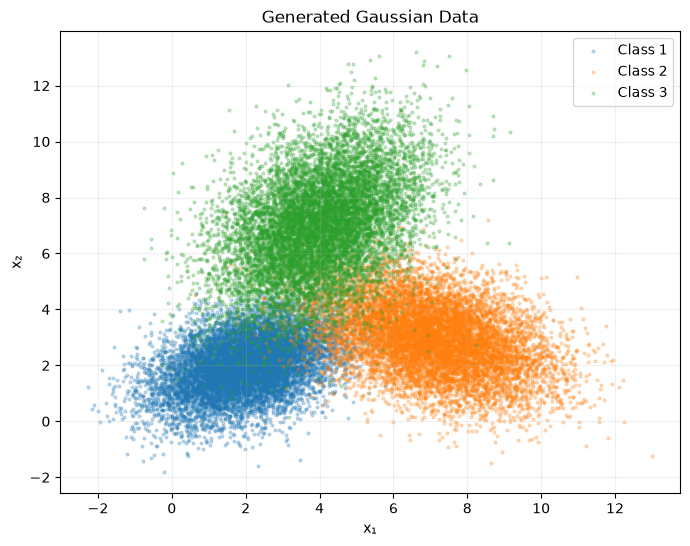

In [6]:

plt.figure(figsize=(8, 6))

for c in np.unique(y):
    plt.scatter(
        X[y == c, 0], X[y == c, 1],
        s=4, alpha=0.25, label=f"Class {c+1}"
    )

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Generated Gaussian Data")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 5. Run all six covariance experiments

In [7]:

def run_experiment(X, y, covariance_mode):
    X_train, X_test, y_train, y_test = split_data(X, y)

    mus, covs, priors = estimate_gaussian_parameters(
        X_train, y_train, covariance_mode=covariance_mode
    )

    y_pred = classify_gaussian(X_test, mus, covs, priors)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_test, y_pred)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "mus": mus,
        "covs": covs,
        "priors": priors,
        "y_pred": y_pred,
        "cm": cm,
        "accuracy": acc
    }


results = {}

for experiment_name, true_covariances in covariance_sets.items():
    X_exp, y_exp = generate_gaussian_data(
        means, true_covariances,
        n_per_class=N_PER_CLASS,
        seed=42
    )

    if "Spherical" in experiment_name:
        mode = "spherical"
    elif "Diagonal" in experiment_name:
        mode = "diagonal"
    else:
        mode = "full"

    results[experiment_name] = run_experiment(X_exp, y_exp, mode)

summary = pd.DataFrame({
    "Experiment": list(results.keys()),
    "Accuracy": [results[k]["accuracy"] for k in results]
})

summary["Accuracy (%)"] = 100 * summary["Accuracy"]
summary[["Experiment", "Accuracy (%)"]].round(3)


,Experiment,Accuracy (%)
0,Spherical - common,93.600
1,Diagonal - common,95.467
2,Full - common,96.333
3,Spherical - different,92.050
4,Diagonal - different,94.317
5,Full - different,94.583


### Estimated parameters for the selected full/different-covariance experiment

In [8]:

selected = results["Full - different"]

for c in [0, 1, 2]:
    print(f"Class {c+1}")
    print("Estimated mean:")
    print(selected["mus"][c])
    print("Estimated covariance:")
    print(selected["covs"][c])
    print()


Class 1
Estimated mean:
[2.00463712 2.01296588]
Estimated covariance:
[[1.51840569 0.4698472 ]
 [0.4698472  1.00556791]]

Class 2
Estimated mean:
[7.00348424 3.01201911]
Estimated covariance:
[[ 2.50404224 -0.76786515]
 [-0.76786515  1.51037034]]

Class 3
Estimated mean:
[3.97394142 6.99607629]
Estimated covariance:
[[1.78005337 0.89657554]
 [0.89657554 2.9585572 ]]



## 6. Confusion matrices

In [9]:

for name, result in results.items():
    print(f"\n{name}")
    print(pd.DataFrame(
        result["cm"],
        index=["Actual 1", "Actual 2", "Actual 3"],
        columns=["Predicted 1", "Predicted 2", "Predicted 3"]
    ))



Spherical - common
          Predicted 1  Predicted 2  Predicted 3
Actual 1         1880           72           48
Actual 2           69         1865           66
Actual 3           58           71         1871

Diagonal - common
          Predicted 1  Predicted 2  Predicted 3
Actual 1         1926            3           71
Actual 2            6         1944           50
Actual 3           85           57         1858

Full - common
          Predicted 1  Predicted 2  Predicted 3
Actual 1         1908           60           32
Actual 2           75         1920            5
Actual 3           41            7         1952

Spherical - different
          Predicted 1  Predicted 2  Predicted 3
Actual 1         1954           23           23
Actual 2           56         1828          116
Actual 3           89          170         1741

Diagonal - different
          Predicted 1  Predicted 2  Predicted 3
Actual 1         1951           20           29
Actual 2           37         1819   

## 7. Decision boundaries and test data

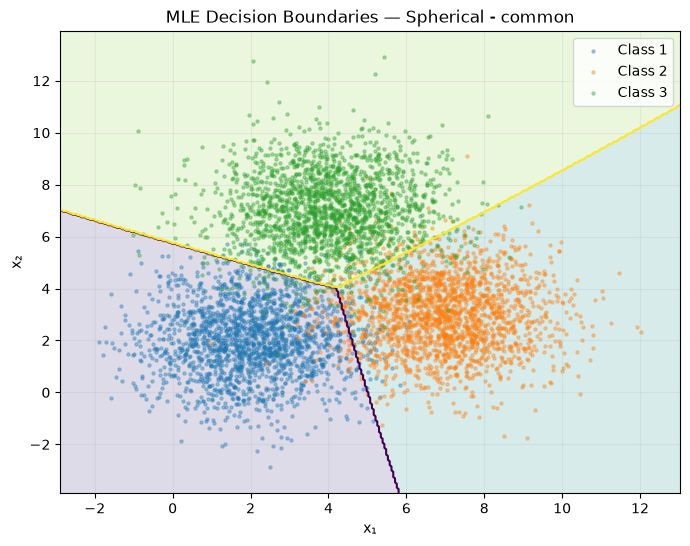

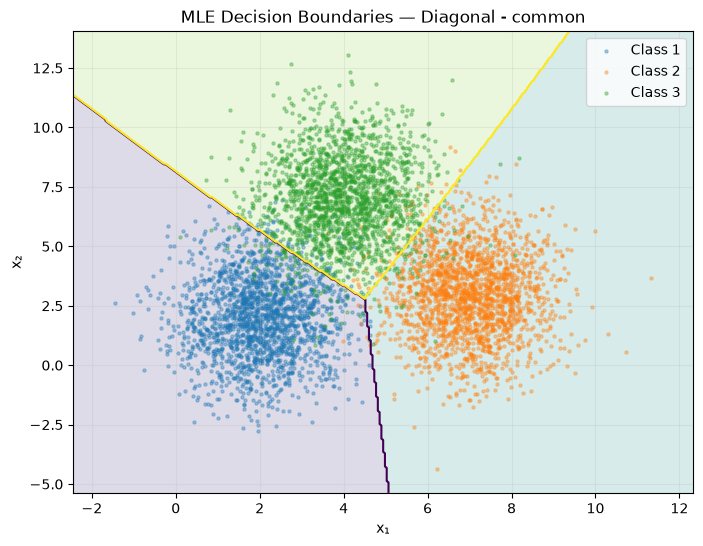

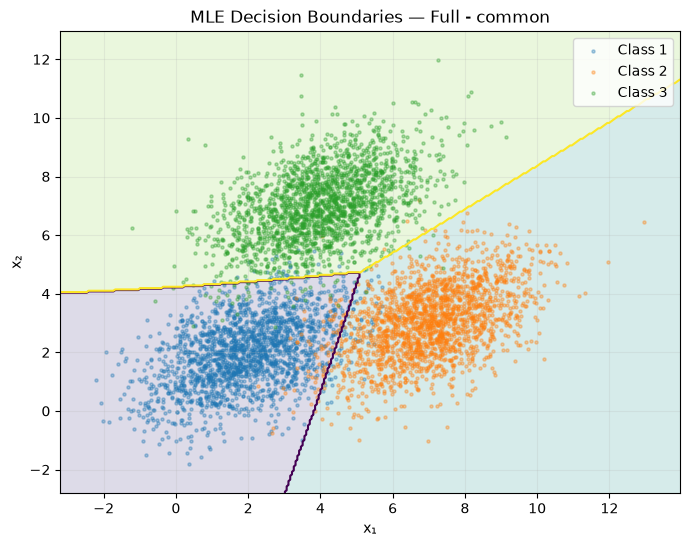

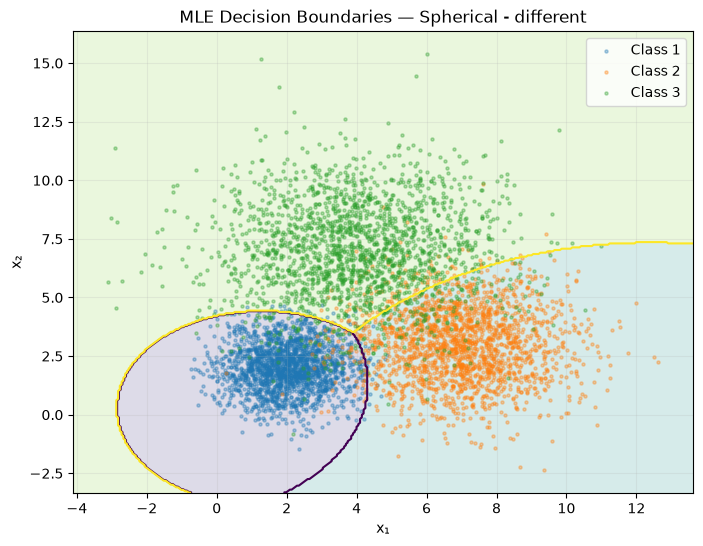

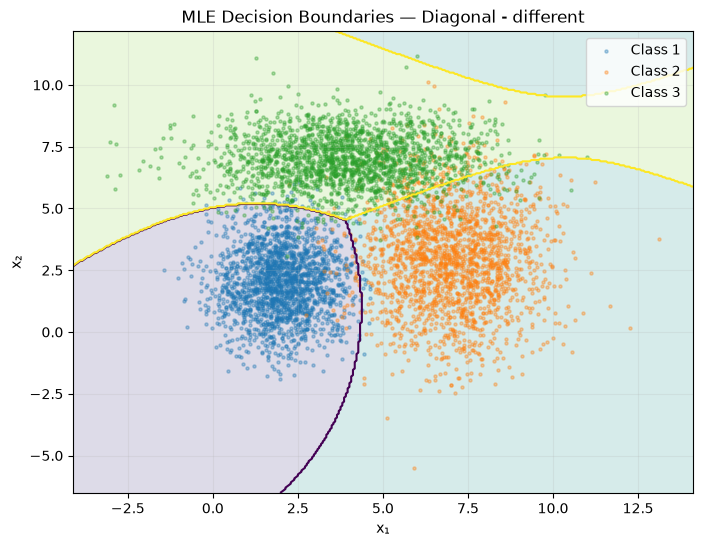

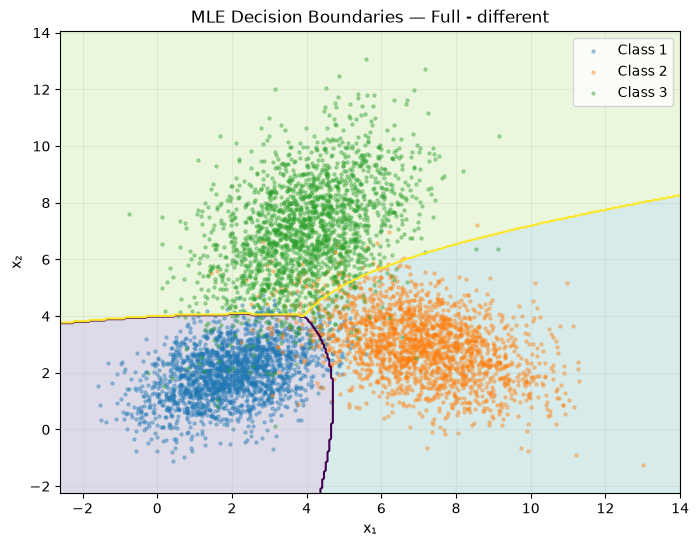

In [10]:

def plot_decision_boundaries(result, title, grid_points=350):
    X_test = result["X_test"]
    y_test = result["y_test"]

    x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
    y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = classify_gaussian(
        grid, result["mus"], result["covs"], result["priors"]
    ).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.18)
    plt.contour(xx, yy, Z, levels=[0.5, 1.5], linewidths=1.5)

    for c in [0, 1, 2]:
        plt.scatter(
            X_test[y_test == c, 0],
            X_test[y_test == c, 1],
            s=5, alpha=0.35,
            label=f"Class {c+1}"
        )

    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


for name, result in results.items():
    plot_decision_boundaries(
        result,
        f"MLE Decision Boundaries — {name}"
    )



## 8. Accuracy and confusion-matrix visualization for the best model

The full covariance model is the most flexible of the three because it retains covariance between features. The following cell identifies the best of the six experiments and displays its confusion matrix.


Best experiment: Full - common
Test accuracy: 0.9633 (96.33%)


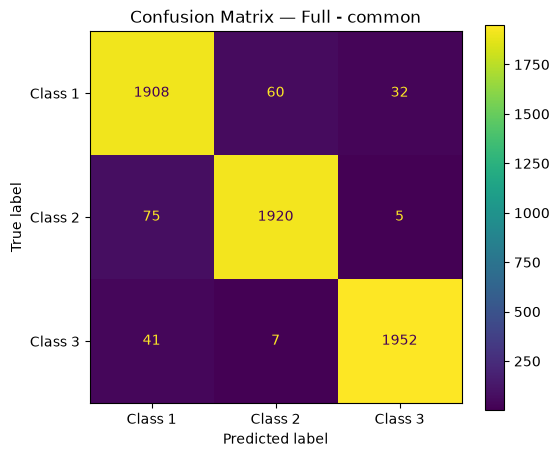

In [11]:

best_name = summary.loc[summary["Accuracy"].idxmax(), "Experiment"]
best = results[best_name]

print("Best experiment:", best_name)
print(f"Test accuracy: {best['accuracy']:.4f} ({100*best['accuracy']:.2f}%)")

disp = ConfusionMatrixDisplay(
    confusion_matrix=best["cm"],
    display_labels=["Class 1", "Class 2", "Class 3"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.show()



## 9. Observations for Part 1

1. **MLE estimates approach the generating parameters** as the number of training samples becomes large. With 8,000 training samples per class, the estimated means and covariance matrices should be close to the parameters used to generate the data.
2. **Spherical covariance** assumes equal variance in every feature direction and zero covariance. Its decision boundaries are therefore more constrained.
3. **Diagonal covariance** allows different variances for the two features but assumes zero covariance between them.
4. **Full covariance** also models correlation between features and can therefore produce more flexible quadratic decision boundaries.
5. When **all classes share the same covariance matrix**, the quadratic terms cancel between class discriminants, giving linear decision boundaries.
6. When **classes have different covariance matrices**, the quadratic terms generally do not cancel, so the decision boundaries become curved.
7. The confusion matrix shows which classes are being confused. Increasing overlap between class distributions generally increases classification errors.



# Part 2 – Real 2-D Dataset

The assignment specifies a 2-D dataset available from the provided Google Drive folder, with a filename suffix matching the team number. The supplied Assignment 5 PDF does **not** contain the actual CSV data or the team number, so the cell below is designed to run once the correct CSV is downloaded and placed beside this notebook.

Expected format:

```text
x, y, class_label
```

The code automatically handles either a header row or a headerless CSV.


In [12]:
import pandas as pd


# Change this to the downloaded team-specific CSV filename.
REAL_DATA_FILE = "team_data.csv"

# Expected columns are x, y, class label.
# If your CSV already has column names, they will be normalized below.

try:
    real_df = pd.read_csv(REAL_DATA_FILE)

    if real_df.shape[1] < 3:
        raise ValueError("The real-data CSV must contain at least three columns: x, y, class label.")

    real_df = real_df.iloc[:, :3].copy()
    real_df.columns = ["x", "y", "class"]

    # Convert numeric-looking values where possible.
    real_df["x"] = pd.to_numeric(real_df["x"], errors="coerce")
    real_df["y"] = pd.to_numeric(real_df["y"], errors="coerce")

    real_df = real_df.dropna(subset=["x", "y", "class"])

    print("Loaded real dataset:", REAL_DATA_FILE)
    print("Number of usable samples:", len(real_df))
    print(real_df.head())

except FileNotFoundError:
    print(
        f"'{REAL_DATA_FILE}' was not found. Download your team-specific CSV "
        "from the Google Drive specified in the assignment and place it "
        "in the same folder as this notebook."
    )


Loaded real dataset: team_data.csv
Number of usable samples: 150
     x    y  class
0  5.1  3.5      0
1  4.9  3.0      0
2  4.7  3.2      0
3  4.6  3.1      0
4  5.0  3.6      0


In [13]:

# Run this cell after the real CSV has been placed beside the notebook.

if "real_df" in globals():
    X_real = real_df[["x", "y"]].to_numpy(float)

    # Encode arbitrary class labels as 0, 1, 2, ...
    class_values = np.sort(real_df["class"].unique())
    class_to_int = {v: i for i, v in enumerate(class_values)}
    y_real = real_df["class"].map(class_to_int).to_numpy()

    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_real, y_real,
        test_size=0.20,
        stratify=y_real,
        random_state=42
    )

    real_classes = np.unique(y_real)

    # Full covariance MLE is used for the real 2-D data.
    real_mus, real_covs, real_priors = estimate_gaussian_parameters(
        Xr_train, yr_train, covariance_mode="full"
    )

    yr_pred = classify_gaussian(
        Xr_test, real_mus, real_covs, real_priors
    )

    real_cm = confusion_matrix(
        yr_test, yr_pred, labels=real_classes
    )

    real_acc = accuracy_score(yr_test, yr_pred)

    print(f"Real-data test accuracy: {100*real_acc:.2f}%")
    print(pd.DataFrame(
        real_cm,
        index=[f"Actual {c}" for c in class_values],
        columns=[f"Predicted {c}" for c in class_values]
    ))


Real-data test accuracy: 70.00%
          Predicted 0  Predicted 1  Predicted 2
Actual 0           10            0            0
Actual 1            0            5            5
Actual 2            0            4            6


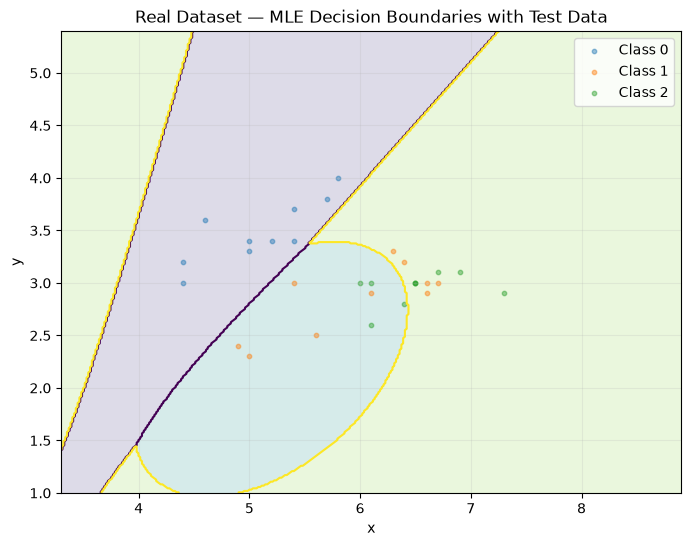

In [14]:

if "real_df" in globals():
    x_min, x_max = X_real[:, 0].min() - 1, X_real[:, 0].max() + 1
    y_min, y_max = X_real[:, 1].min() - 1, X_real[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = classify_gaussian(
        grid, real_mus, real_covs, real_priors
    ).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(
        xx, yy, Z,
        levels=np.arange(len(real_classes) + 1) - 0.5,
        alpha=0.18
    )
    plt.contour(
        xx, yy, Z,
        levels=np.arange(len(real_classes) - 1) + 0.5,
        linewidths=1.5
    )

    for c in real_classes:
        plt.scatter(
            Xr_test[yr_test == c, 0],
            Xr_test[yr_test == c, 1],
            s=10, alpha=0.45,
            label=f"Class {class_values[c]}"
        )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Real Dataset — MLE Decision Boundaries with Test Data")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()



## Observations for Part 2

After running the real-data cells with the team-specific CSV, report:

- the number of samples in each class;
- the estimated mean vector of each class;
- the estimated covariance matrix of each class;
- the 80/20 train-test split;
- test-set accuracy;
- the confusion matrix;
- which class pairs are most frequently confused;
- whether the decision boundaries appear linear or quadratic and whether this agrees with the covariance structure.

**Note:** The actual real-data numerical observations cannot be completed from the supplied PDF alone because the PDF provides the Google Drive location but not the team-specific CSV itself.



## Final conclusion

Maximum likelihood estimation provides the mean and covariance parameters needed to construct Gaussian class-conditional models. The covariance assumption directly affects the shape and flexibility of the classifier:

- **Spherical:** simplest covariance model.
- **Diagonal:** independent features with unequal variances.
- **Full:** includes feature correlation and gives the most flexible Gaussian model.

For common covariance matrices, the Gaussian decision boundaries are linear; for class-specific covariance matrices, they are generally quadratic.
